# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy  

## Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships, and differences in the available data.

> **Important:** This is a Data Analytics project. The focus is on data cleaning, exploration, statistical analysis, visualization, and deriving meaningful insights. No Machine Learning or dashboard development is required.

## 1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

## 2. Project Objectives
The primary objective of this project is to analyze agricultural data from different seasons
and identify meaningful patterns, trends, relationships and differences in agricultural
performance.

The main objectives are:

- Explore and understand the dataset.
- Clean and prepare the data for analysis.
- Examine agricultural performance across seasons.
- Identify important seasonal patterns and trends.
- Investigate relationships between environmental conditions and agricultural outcomes.
- Compare relevant groups across seasons.
- Identify significant differences and unusual patterns.
- Apply suitable statistical and visualization techniques.
- Interpret findings based on the available data.
- Develop meaningful conclusions and data-driven recommendations.

## 3. Dataset

The dataset contains agricultural information collected across different seasons, geographical areas, crops, farming conditions, environmental conditions, resource usage, and economic performance.

**Dataset file**: seasonal_agriculture_performance_dataset.csv

In [348]:
#Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [349]:
%matplotlib inline
sns.set_theme(style="whitegrid")
# Display all columns when viewing the dataset
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [350]:
#Load the dataset

df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfuly!")

Dataset loaded successfuly!


### 4. Intial Data Understanding

In [351]:
#Top 5 rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [352]:
#Bottom 5 rows

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [353]:
#Dataset shape
print("The Shape of the dataset:", df.shape)
print("Total rows   :", df.shape[0])
print("Total columns:", df.shape[1])

The Shape of the dataset: (4000, 28)
Total rows   : 4000
Total columns: 28


In [354]:
# Column names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [355]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [356]:
# Numerical summary statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [357]:
# Categorical Summary
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


## 5. Data Quality Analysis
Before performing the analysis, the dataset was examined to understand its structure and identify possible data quality issues.

The following checks were performed:

- Column names and data types
- Missing values
- Duplicate records
- Unique categorical values
- Summary statistics

These checks help ensure that the dataset is suitable for further analysis.

In [358]:
# Missing Values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean()* 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


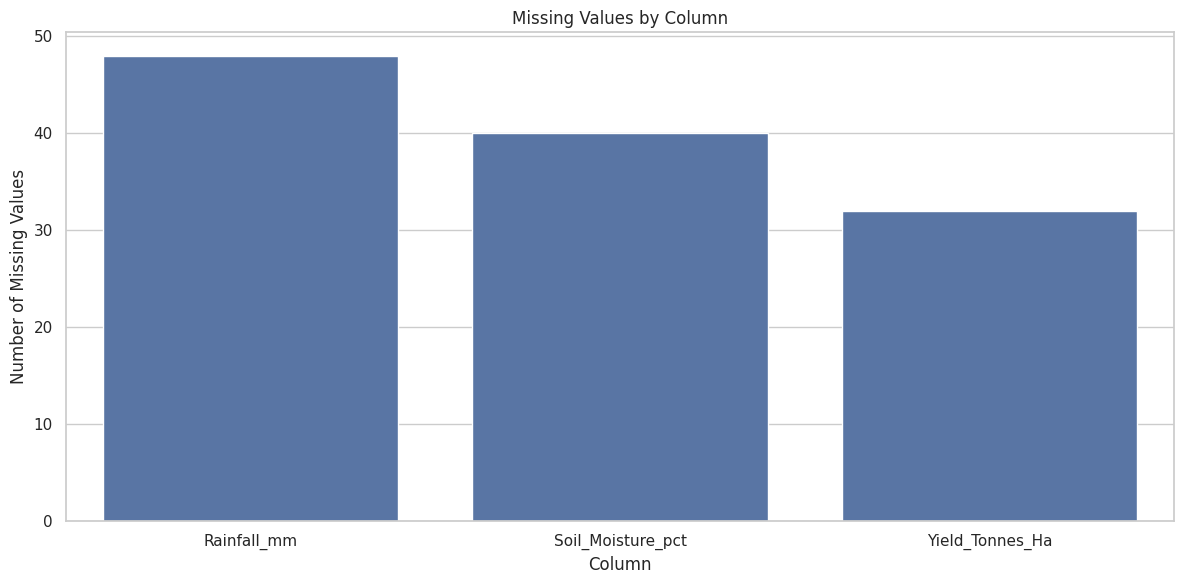

In [359]:
# Visualize missing values
plt.figure(figsize=(12,6))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
  sns.barplot(x=missing_plot.index, y=missing_plot.values)
  plt.xlabel("Column")
  plt.ylabel("Number of Missing Values")
  plt.title("Missing Values by Column")
  plt.tight_layout()
  plt.show()
else:
  print("No missing values found.")


In [360]:
#Duplicate records
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [361]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [362]:
# Check data types
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [363]:
# Check unique values for categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
  print(f"\n{col}:")
  print(df[col].nunique(), "unique values")
  print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [364]:
# Check missing values after duplicate removal
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


## 6. Missing Value Treatment
Missing values were identified in the dataset.

For numerical columns, missing values were replaced using the median value of the respective column.

In [365]:
#Example: median imputation for numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns
for col in numerical_columns:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:", df.isnull().sum().sum())
print("Missing values handled successfully!")

Remaining missing values: 0
Missing values handled successfully!


In [366]:
#Numerical and categorical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


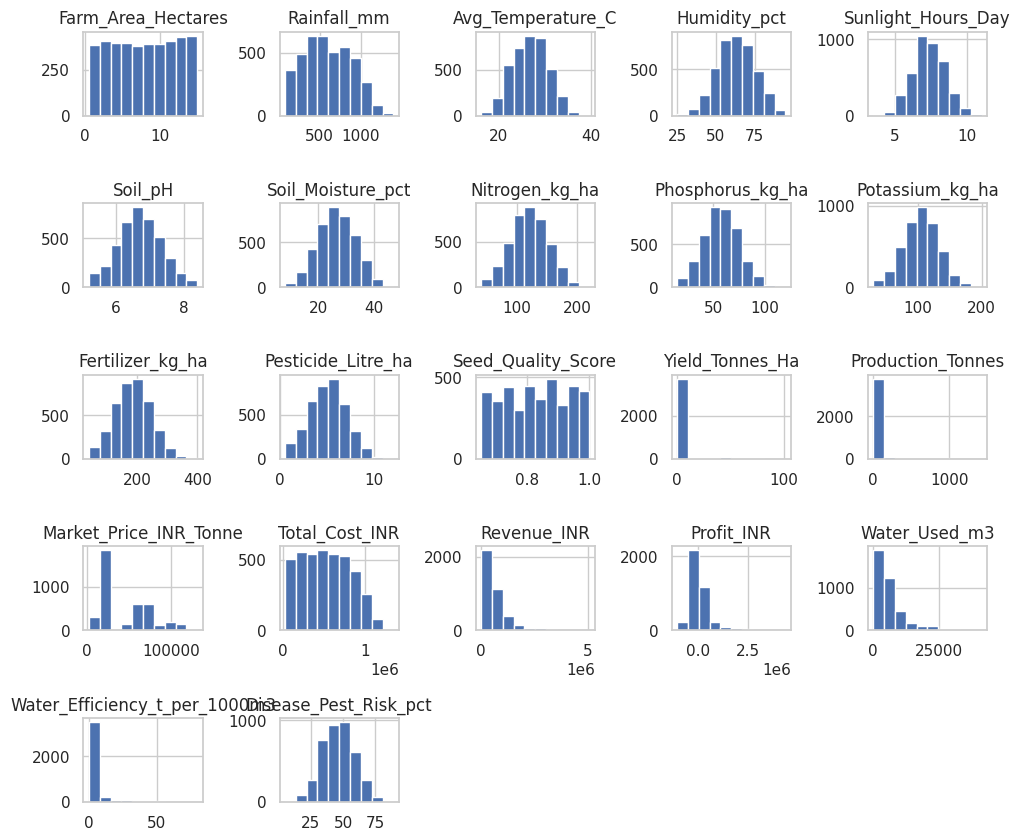

In [367]:
df.hist(bins=10, layout=(6,5),figsize=(10,10))
plt.tight_layout()
plt.show()

## 7. Satistical Analysis

In [368]:
#Descriptive Statistics
stats = df[numerical_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [369]:
#Median and standard deviation
satistical_summary = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Std_Dev": df[numerical_columns].std(),
    "Min": df[numerical_columns].min(),
    "Max": df[numerical_columns].max()
})
satistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [370]:
#Seasonal descriptive summary
season_summary = df.groupby("Season")[numerical_columns].agg(["mean", "median", "std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

## 8. Univariate Analysis
Univariate analysis examines one variable at a time. This analysis helps understand the distribution and frequency of important agricultural variables.

The analysis includes season and crop distributions, as well as the distributions of yield, profit, rainfall, and other important numerical variables.

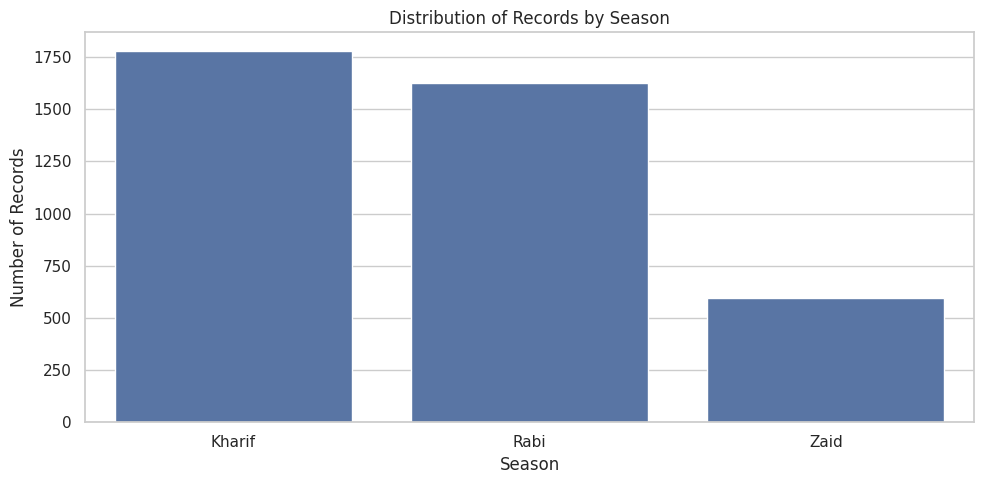

In [371]:
#Univariate: Season distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

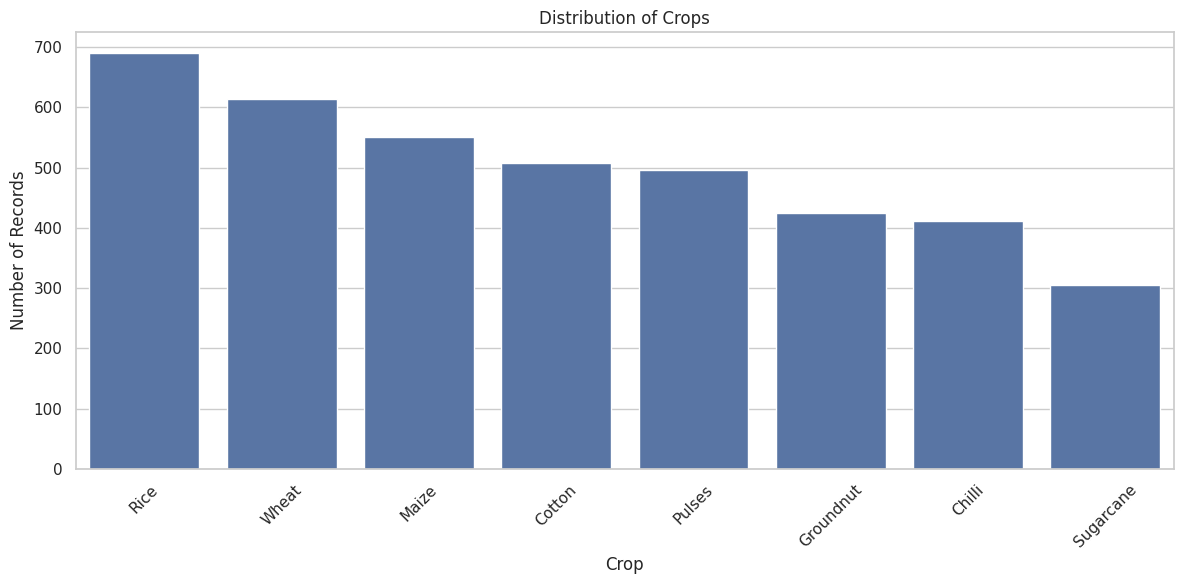

In [372]:
#Univariate: Crop distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

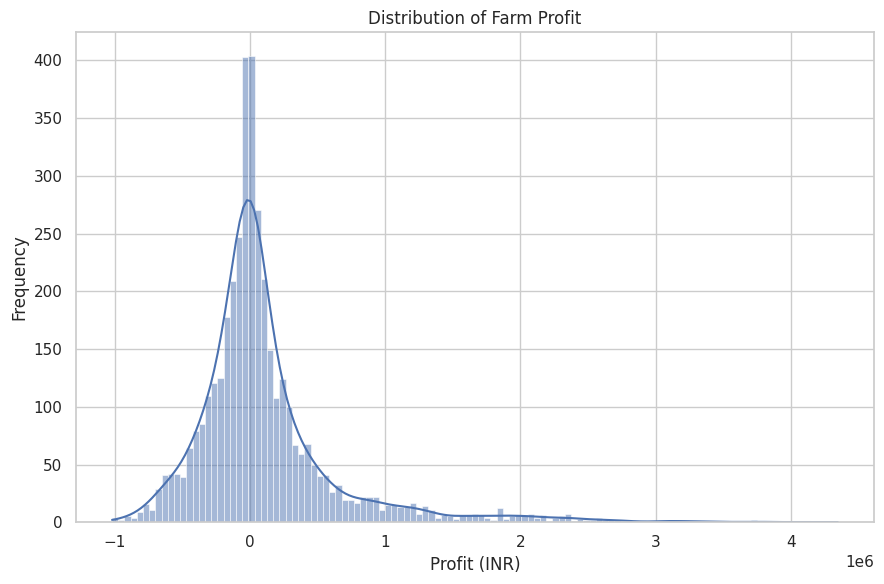

In [373]:
#Univariate: Profit distribution
plt.figure(figsize=(9,6))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

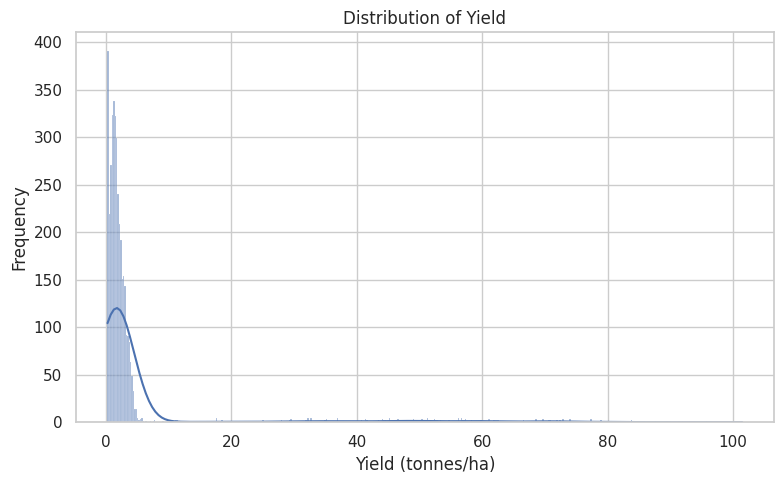

In [374]:
##Univariate: Yield distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

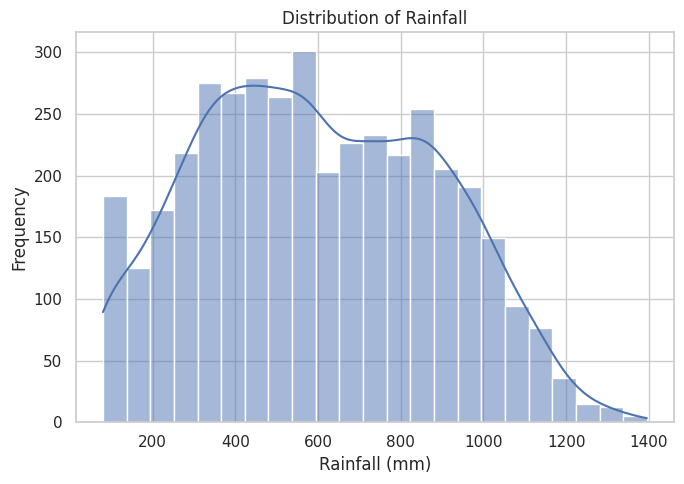

In [375]:
#Univariate: Rainfall distribution
plt.figure(figsize=(7,5))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

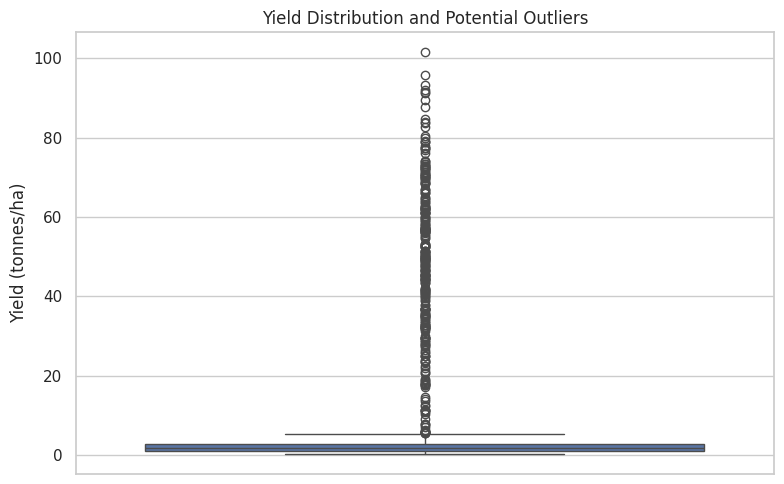

In [376]:
#Univariate: Boxplot for yield
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

## Univariate: Season distribution (Pie Chart)

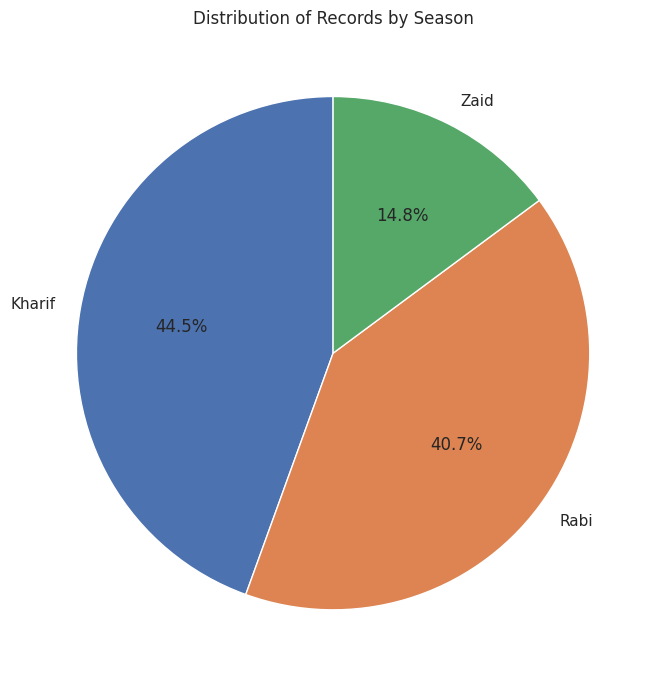

In [377]:
plt.figure(figsize=(7,7))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Records by Season')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 9. Outlier Analysis
Potential outliers were identified using boxplots and the Interquartile Range (IQR) method.

The identified outliers were investigated but were not removed from the dataset because extreme values in agricultural data may represent genuine differences in crop yield, farm size, production, water usage, or economic performance.

Therefore, the observations were retained for further analysis unless there was clear evidence that they were caused by data-entry or measurement errors.

In [378]:
#IQR-based outlier summary for numerical columns
outlier_summary = []

for col in numerical_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  count = ((df[col] < lower) | (df[col] > upper)).sum()

  outlier_summary.append({
      "Column":col,
      "Outlier_Count": count,
      "Lower_Bound":lower,
      "Upper_Bound":upper,
      "Outlier_Percentage": round(count / len(df) * 100,2)
  })
outlier_summary = pd.DataFrame(outlier_summary).sort_values("Outlier_Count", ascending=False)

outlier_summary

,Column,Outlier_Count,Lower_Bound,Upper_Bound,Outlier_Percentage
18,Profit_INR,404,"-696,111.00","763,567.00",10.10
14,Production_Tonnes,333,-23.98,53.36,8.33
20,Water_Efficiency_t_per_1000m3,322,-3.57,10.38,8.05
13,Yield_Tonnes_Ha,302,-1.62,5.50,7.55
19,Water_Used_m3,276,"-6,072.75","16,171.25",6.90
17,Revenue_INR,240,"-736,519.00","1,780,911.00",6.00
9,Potassium_kg_ha,32,30.10,179.70,0.80
4,Sunlight_Hours_Day,26,4.35,10.35,0.65
8,Phosphorus_kg_ha,16,11.40,104.20,0.40
10,Fertilizer_kg_ha,15,19.14,352.04,0.38


In [379]:
columns_to_check = [
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Used_m3'
]

for column in columns_to_check:
    # Retrieve the outlier count from the already computed outlier_summary DataFrame
    outlier_count = outlier_summary[outlier_summary['Column'] == column]['Outlier_Count'].iloc[0]
    print(column, ":", outlier_count, "potential outliers")

Yield_Tonnes_Ha : 302 potential outliers
Profit_INR : 404 potential outliers
Water_Used_m3 : 276 potential outliers


## 10. Bivariate Analysis
Bivariate analysis examines the relationship between two variables.

The analysis compares seasonal performance and explores relationships such as rainfall and yield, farm area and production, and irrigation methods and yield.

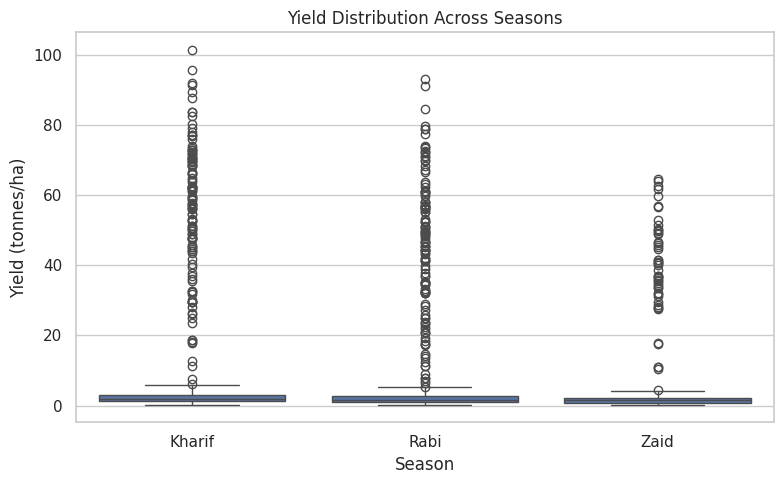

In [380]:
#Bivariate: Season vs Yield
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

In [381]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print(season_yield.round(2))

Season
Kharif   5.63
Rabi     5.04
Zaid     4.64
Name: Yield_Tonnes_Ha, dtype: float64


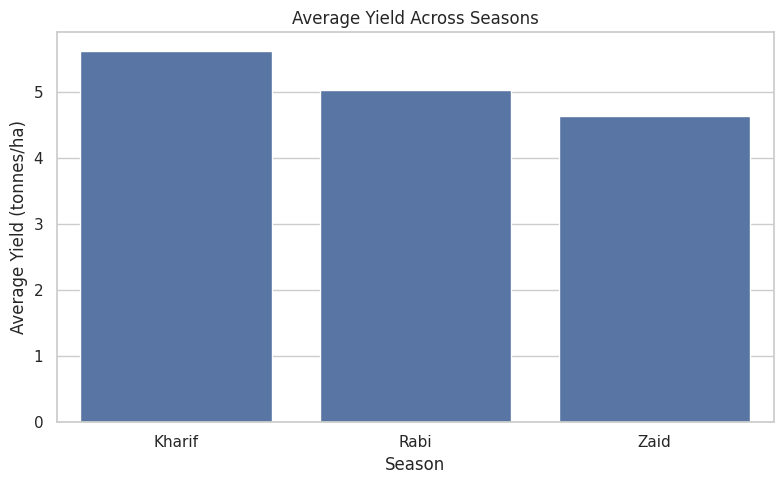

In [382]:
#Bivariate: Season vs Average Yield
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

In [383]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

print(season_profit.round(2))

Season
Kharif   178,914.65
Rabi      87,689.47
Zaid     -24,804.82
Name: Profit_INR, dtype: float64


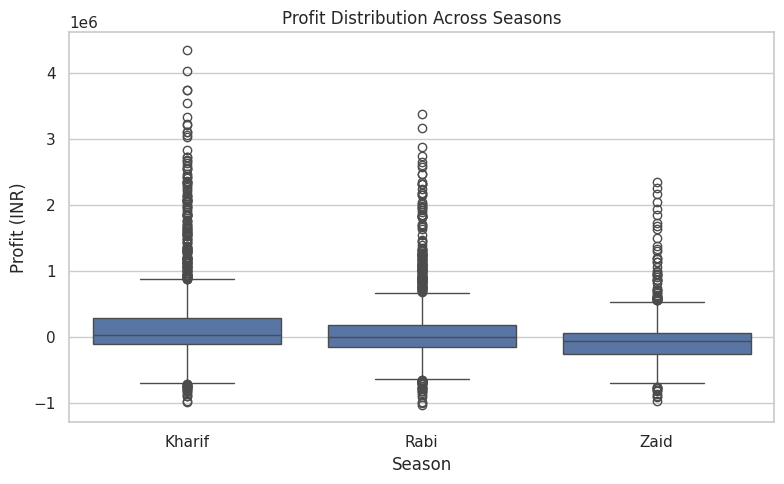

In [384]:
#Bivariate: Season vs Profit
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Season", y="Profit_INR")
plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

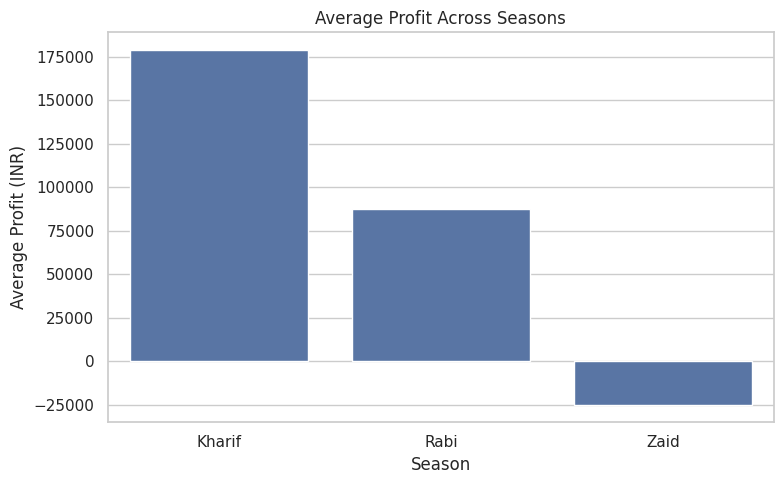

In [385]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Profit_INR", errorbar=None)
plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

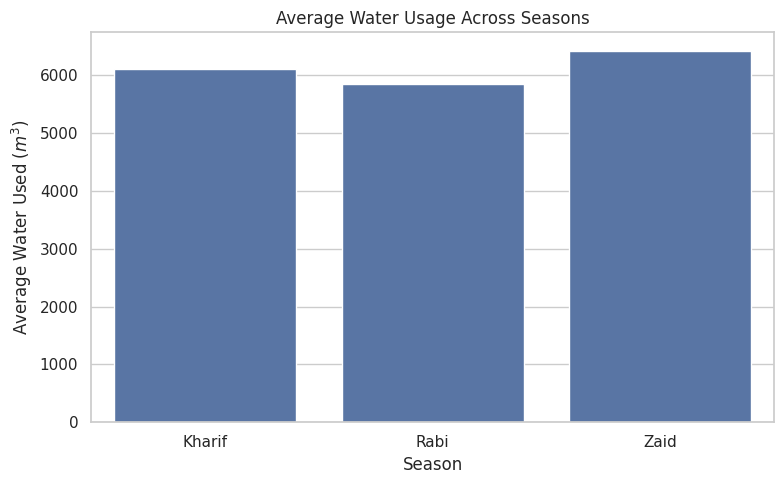

In [386]:
#Season vs Water Usage
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Season", y="Water_Used_m3", errorbar=None)
plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Water Used ($m^3$)")
plt.tight_layout()
plt.show()

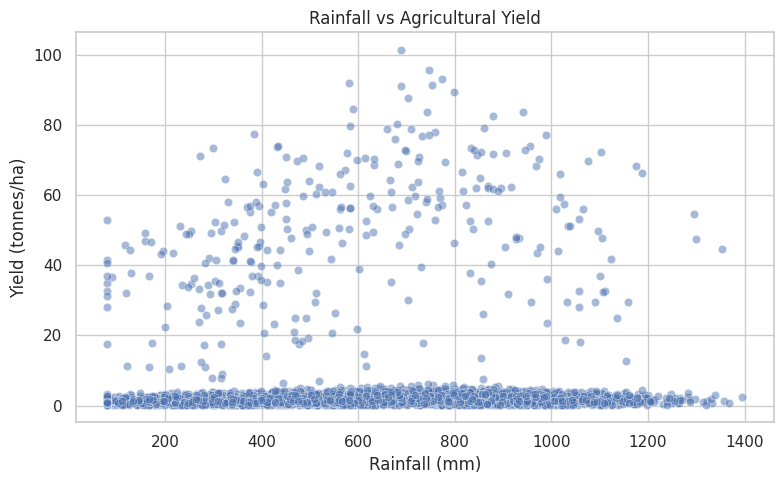

In [387]:
#Rainfall vs Yield
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

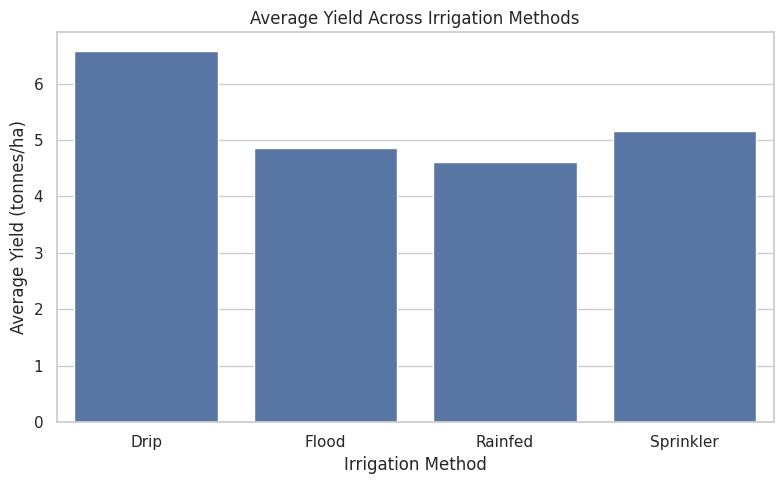

In [388]:
#Bivariate: Average Yield Across Irrigation Methods(Bar Plot)
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", errorbar=None)
plt.title("Average Yield Across Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

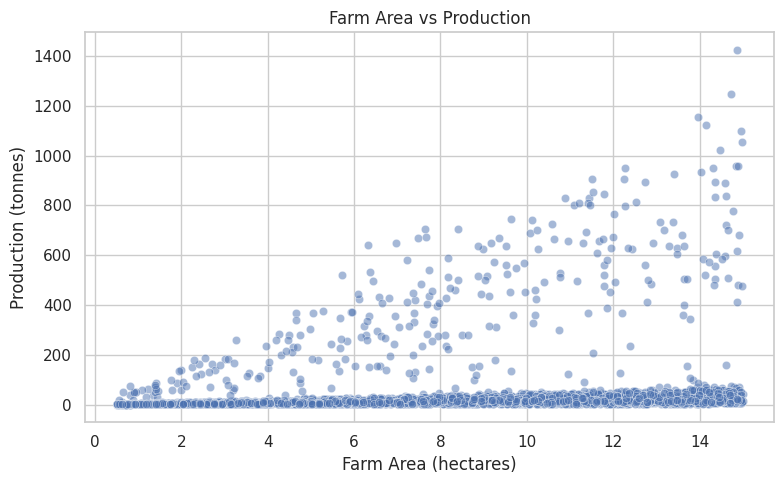

In [389]:
#Bivariate: Farm area vs Production
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

## 11. Multivariate Analysis
Multivariate analysis examines multiple variables together to understand how different factors are related to agricultural performance.

The analysis considers combinations of season, crop, environmental conditions, farm size, yield, profit, and other agricultural factors.

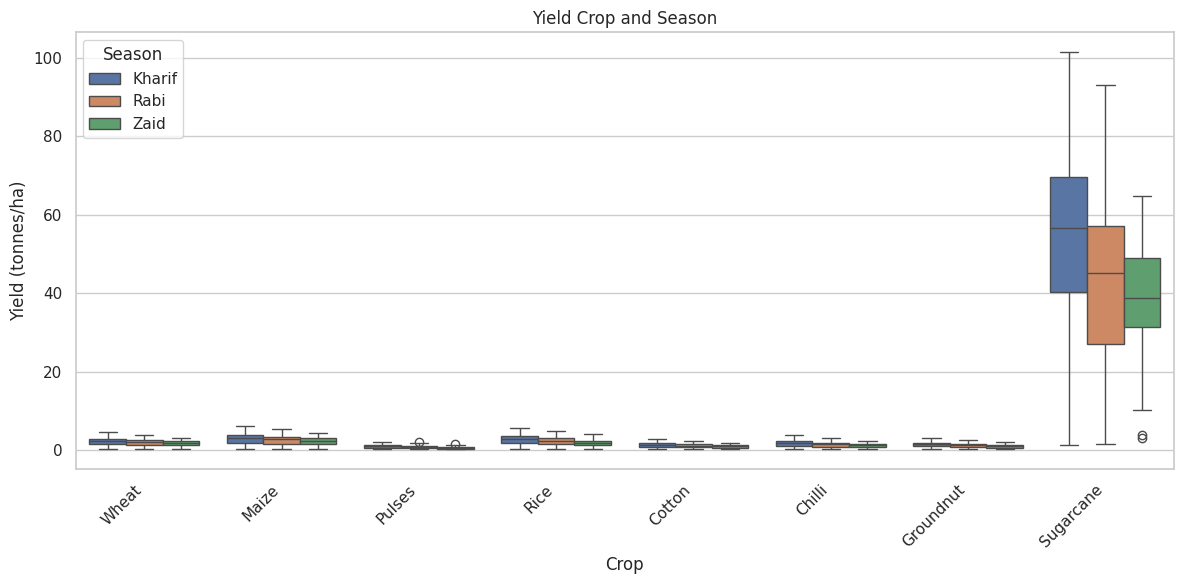

In [390]:
#Multivariate: Season, crop and yield
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season")
plt.xticks(rotation=45, ha="right")
plt.title("Yield Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

## Multivariate: Grouped Bar Plot of Average Yield by Crop and Season

In [391]:
crop_season_summary = (
    df.groupby(["Season", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3",
            "mean"
        )
    )
    .round(2)
    .sort_values(
        ["Season", "Average_Yield"],
        ascending=[True, False]
    )
)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

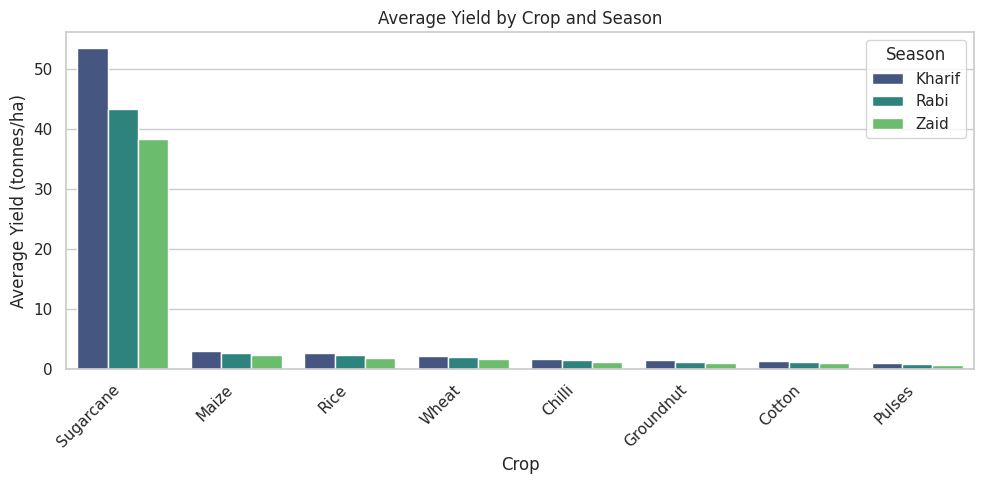

In [392]:
plt.figure(figsize=(10,5))
sns.barplot(data=crop_season_summary.reset_index(), x="Crop", y="Average_Yield", hue="Season", palette='viridis')
plt.xticks(rotation=45, ha="right")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

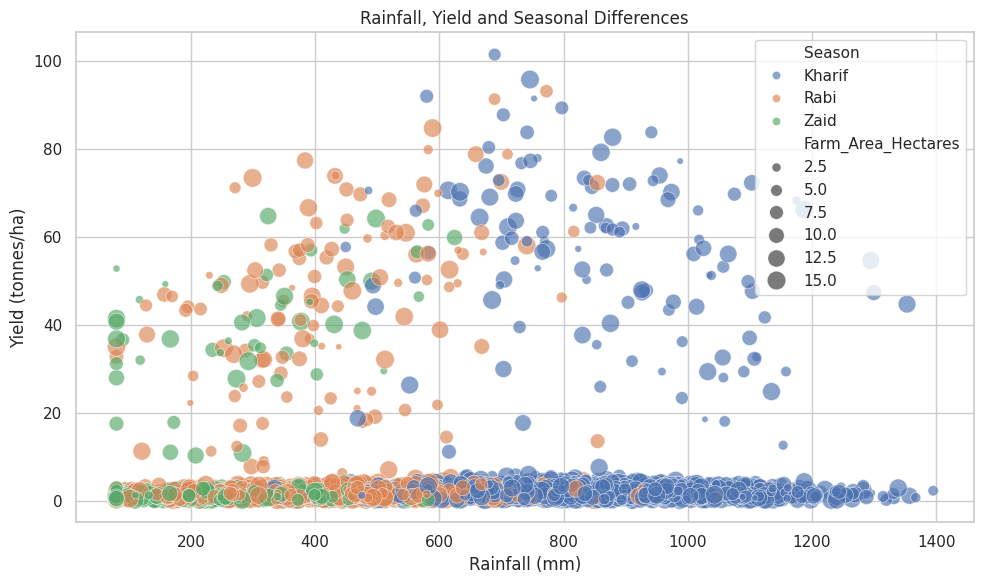

In [393]:
#Multivariate: Rainfall, yield and Season
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20,180),
    alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

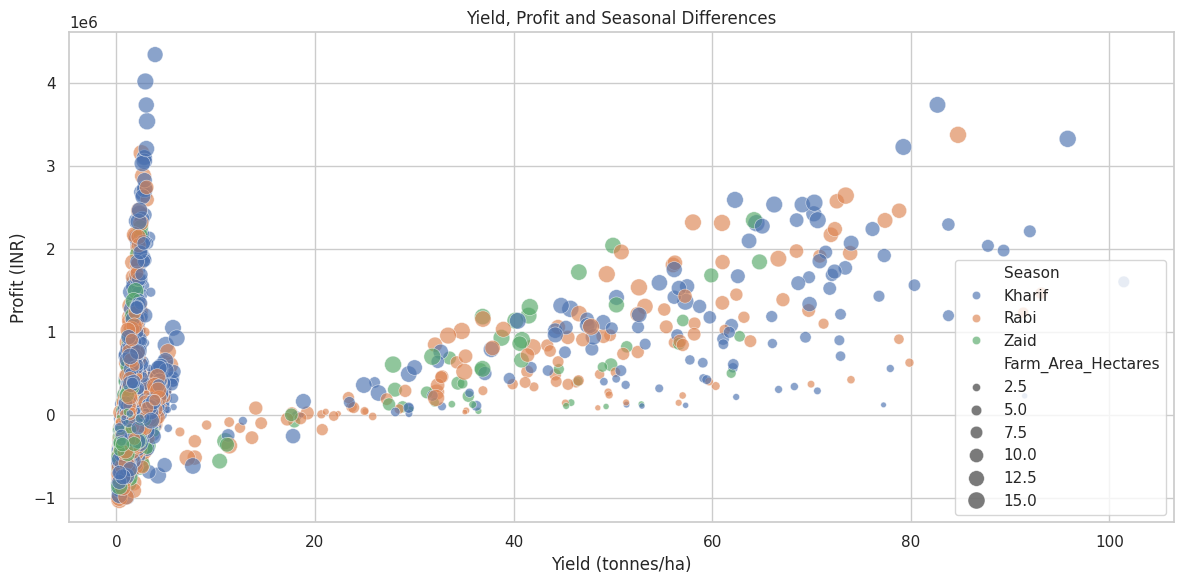

In [394]:
#Multivariate: Profit, yield and season
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(15,150),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


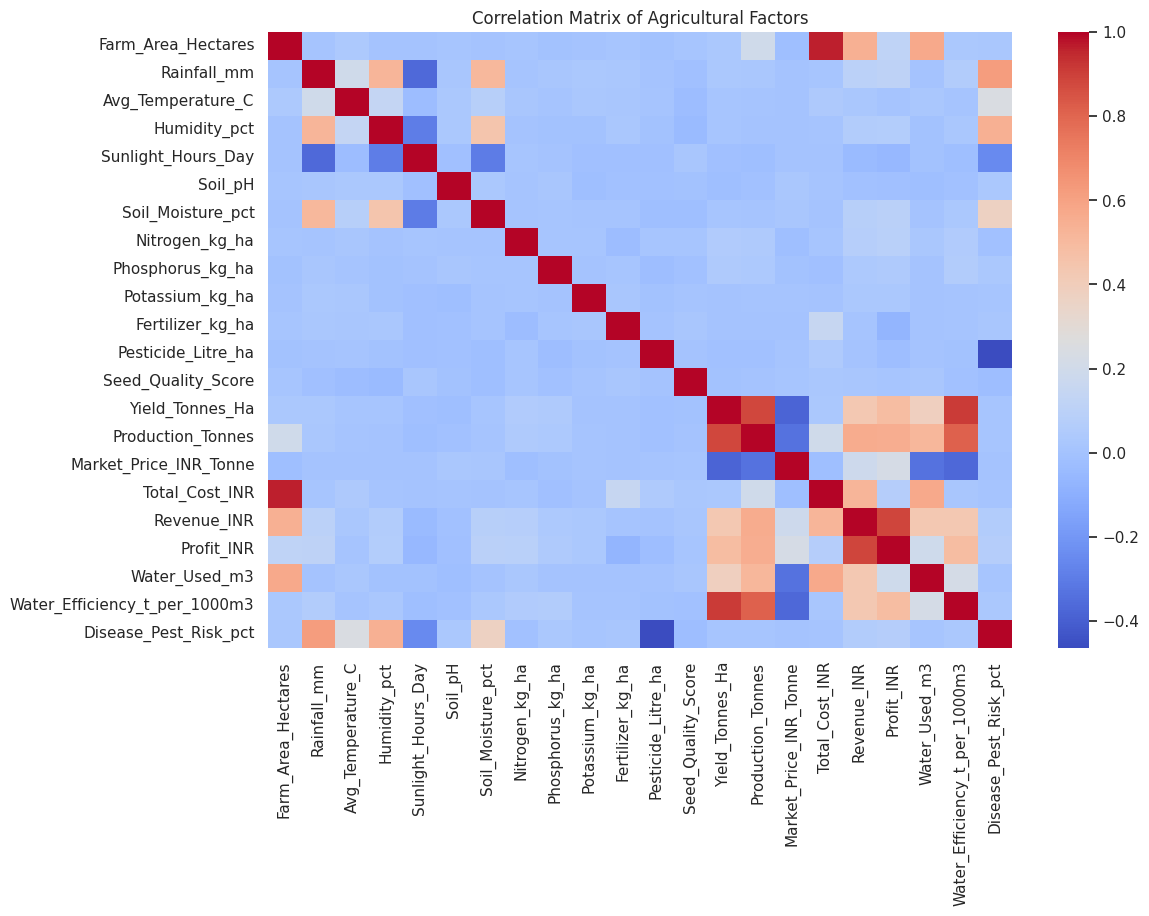

In [395]:
#Correlation heatmap for numerical variables
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_columns].corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Agricultural Factors')
plt.show()

## 12. Seasonal Comparison

In [396]:
#season summary
season_summary = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Average_Disease_Pest_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

season_summary

,Records,Average_Yield,Total_Production,Average_Revenue,Average_Profit,Total_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Disease_Pest_Risk
Season,,,,,,,,,
Kharif,1779,5.63,"82,387.61","710,719.06","178,914.65",318289158,"6,102.20",5.89,54.47
Rabi,1627,5.04,"67,498.88","601,526.05","87,689.47",142670768,"5,846.99",5.19,40.48
Zaid,594,4.64,"23,098.35","519,171.90","-24,804.82",-14734066,"6,419.89",4.41,38.22


In [397]:
#ENVIRONMENTAL ANALYSIS
environment_summary = df.groupby("Season").agg(
    Rainfall=("Rainfall_mm", "mean"),
    Temperature=("Avg_Temperature_C", "mean"),
    Humidity=("Humidity_pct", "mean"),
    Sunlight=("Sunlight_Hours_Day", "mean"),
    Soil_Moisture=("Soil_Moisture_pct", "mean")
).round(2)

print("\nEnvironmental Conditions:")
display(environment_summary)



Environmental Conditions:


,Rainfall,Temperature,Humidity,Sunlight,Soil_Moisture
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


In [398]:
#Compare crop performance within each season
crop_season_summary = (
    df.groupby(["Season", "Crop"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3","mean")
    )
    .round(2)
    .sort_values(["Season", "Average_Yield"], ascending=[True, False])
)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

## 13. Additional Student-Driven Analysis


## Analysis 1

### Question:
Which season has the highest financial risk based on the percentage of farms making a loss?

### Analysis:
Average profit alone does not show how frequently farmers experience losses.

In this analysis, farms with negative profit are identified and the percentage of loss-making farms is calculated for each season.

This helps identify which season has greater financial risk.

### Visualization:
A bar chart will be used to compare the percentage of farms making losses across Kharif, Rabi, and Zaid seasons.

In [399]:
# Identify farms making a loss
df['Loss_Making'] = df['Profit_INR'] < 0

# Calculate percentage of loss-making farms by season
loss_percentage = (
    df.groupby('Season')['Loss_Making']
      .mean()
      .mul(100)
      .round(2)
)

print("Percentage of Farms Making Losses:")
print(loss_percentage)

Percentage of Farms Making Losses:
Season
Kharif   42.21
Rabi     51.14
Zaid     64.48
Name: Loss_Making, dtype: float64


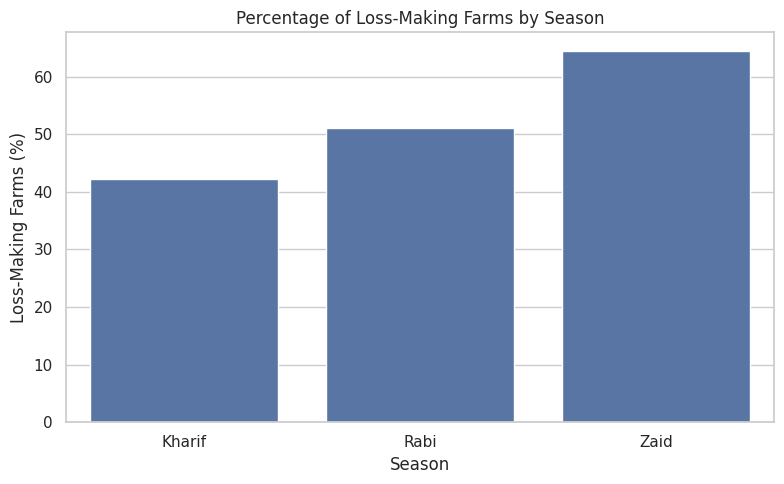

In [400]:
# Visualization:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=loss_percentage.index,
    y=loss_percentage.values
)

plt.title('Percentage of Loss-Making Farms by Season')
plt.xlabel('Season')
plt.ylabel('Loss-Making Farms (%)')
plt.tight_layout()
plt.show()

## Analysis 2

### Question:
Does higher disease and pest risk correspond to lower crop yield?

### Analysis:
Disease and pest pressure can affect agricultural performance.

In this analysis, the relationship between disease/pest risk and crop yield is examined to determine whether farms with higher disease or pest risk tend to have lower yields.

### Visualization:
A scatter plot will be used to visualize the relationship between disease/pest risk and crop yield.

In [401]:
# Calculate the correlation between disease/pest risk and yield
disease_yield_corr = df[
    ['Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha']
].corr().iloc[0, 1]

print("Correlation between Disease/Pest Risk and Yield:",
      round(disease_yield_corr, 3))

Correlation between Disease/Pest Risk and Yield: 0.014


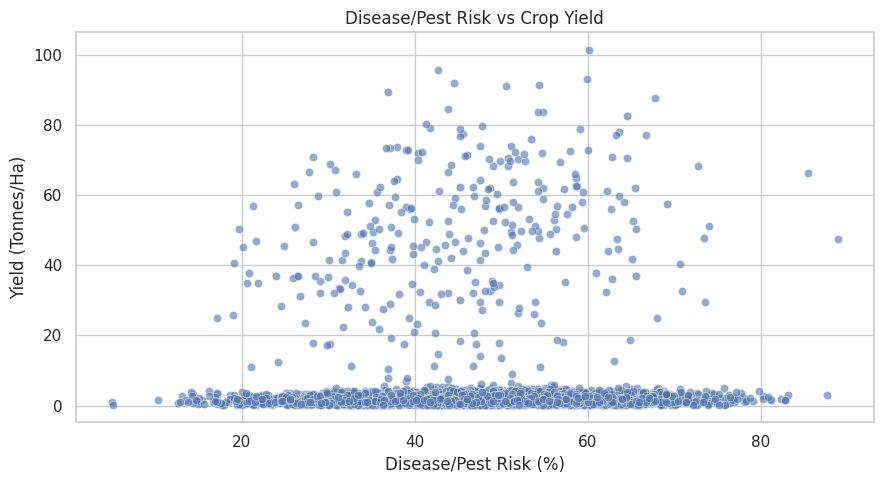

In [402]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Disease_Pest_Risk_pct',
    y='Yield_Tonnes_Ha',
    alpha=0.6
)

plt.title('Disease/Pest Risk vs Crop Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

## Analysis 3

### Question:
Which states show the highest and lowest overall agricultural performance?

### Analysis:
Agricultural performance may vary across different geographical areas. In this analysis, the average crop yield and average profit are compared across states to identify differences in agricultural performance.

This analysis helps identify states with relatively stronger or weaker overall agricultural outcomes.

### Visualization:
A bar chart will be used to compare the average yield across different states.


In [403]:
# Calculate average yield and profit for each state

state_performance = (
    df.groupby('State')
      .agg(
          Average_Yield=('Yield_Tonnes_Ha', 'mean'),
          Average_Profit=('Profit_INR', 'mean')
      )
      .sort_values('Average_Yield', ascending=False)
)

print("State-wise Agricultural Performance:")
print(state_performance.round(2))

State-wise Agricultural Performance:
                Average_Yield  Average_Profit
State                                        
Punjab                   6.12      136,025.64
Karnataka                5.69      119,422.34
Gujarat                  5.66      117,568.24
Telangana                5.04      108,829.62
Maharashtra              5.02      135,428.86
Madhya Pradesh           4.99       86,840.76
Tamil Nadu               4.88      117,744.75
Andhra Pradesh           4.63       73,453.53


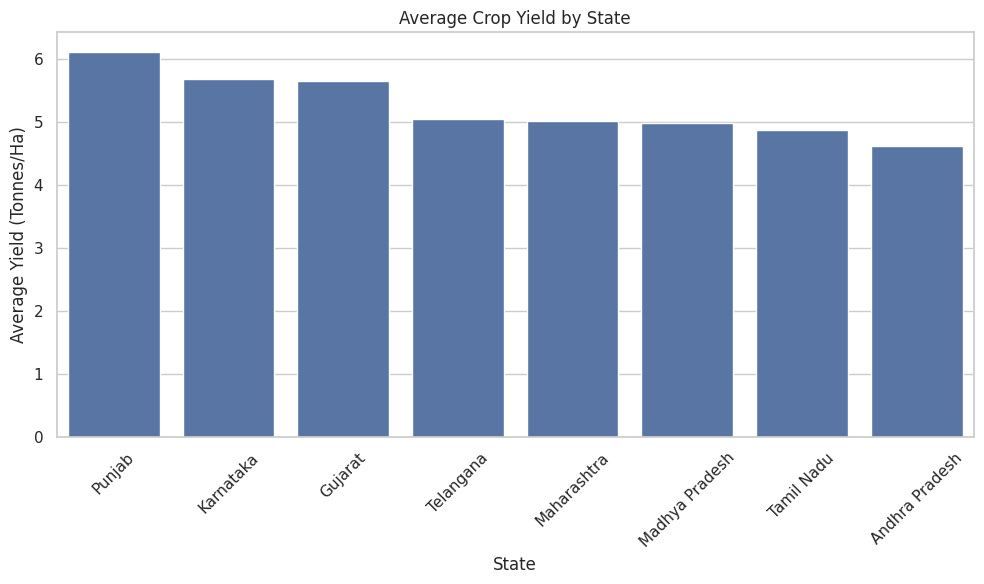

In [404]:
#Visualization:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_performance.reset_index(),
    x='State',
    y='Average_Yield'
)

plt.title('Average Crop Yield by State')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Key Insights

1. Agricultural performance varies across different seasons.

2. Kharif shows comparatively better overall yield and profitability.

3. Zaid shows comparatively weaker economic performance.

4. Zaid has higher water usage and lower water-use efficiency.

5. Disease and pest risk is higher in Kharif compared with other seasons.

6. Water efficiency has a strong positive relationship with crop yield.

7. Disease and pest risk shows little linear relationship with crop yield.

8. Crop yield varies across different states.

9. Crop performance differs across seasons, indicating the importance of seasonal planning.

10. Agricultural performance depends on multiple factors rather than a single variable.

## 15. Recommendations
- Improve water-use efficiency, especially during Zaid.
- Give greater attention to water management in seasons with high water usage.
- Consider financial risk when planning seasonal agricultural activities.
- Give additional attention to disease and pest management during Kharif.
- Consider state-wise differences when planning agricultural activities.
- Evaluate agricultural performance using yield, profit, water efficiency, and risk together.


## 16. Conclusion

The analysis showed that agricultural performance varies across seasons and states.

Kharif recorded comparatively higher yield and profit, while Zaid showed lower profitability, higher financial risk, higher water usage, and lower water efficiency.

Water efficiency showed a strong positive relationship with yield, while disease/pest risk showed almost no linear relationship with yield.

Overall, the analysis demonstrates how data analytics can help identify agricultural patterns, compare performance, and support evidence-based seasonal planning.
